# Final Model - Depression Risk Classification

**Objective:** Build a machine learning model to classify depression risk into three categories: **Low, Medium, and High**.

**Data Integration:** After studying each dataset independently, we identified common and important features from both datasets. We will merge them into one unified dataset, prepare all necessary features, train our model, and analyze the results.

**Scope:** Data loading, Rescaling ,merging, EDA, feature preparation, model training, and depression risk classification.

# Introduction

Our approach combines data from two independent sources with the same important features. By merging these datasets and using machine learning, we can predict whether a student is at low, medium, or high risk of depression.

**Workflow:**
- **Load & Explore:** Import and understand both datasets
- **Handle Ranges (Rescaling)**
- **Merge Data:** Create one unified dataset
- **Train & Analyze:** Build prediction models and analyze results
- **Classify Risk:** Categorize students into risk levels

# Notebook Setup

In [16]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Section 1 : Data Loading & Initial Overview

### Objective
Load the datasets and obtain fundamental information about its structure, dimensions, and data types.


In [17]:
# Load the dataset

ds_a = pd.read_csv('/content/ds_a.csv')
ds_b = pd.read_csv('/content/ds_b.csv')

#### Dataset A

In [18]:
# Display basic information
print("="*80)
print("DATASET DIMENSIONS")
print("="*80)
print(f"Rows: {ds_a.shape[0]:,}")
print(f"Columns: {ds_a.shape[1]}")

print("First Few Records:")
print("=" * 80)
ds_a.head()

DATASET DIMENSIONS
Rows: 27,901
Columns: 5
First Few Records:


,CGPA,Sleep Duration,Work/Study Hours,Academic Pressure,Depression
0,8.97,5.5,3,5,1
1,5.90,5.5,3,2,0
2,7.03,4.5,9,3,0
3,5.59,7.5,4,3,1
4,8.13,5.5,1,4,0


In [19]:
# Display column names and target distribution
print("="*80)
print("COLUMN NAMES & DATA TYPES")
print("="*80)
print(ds_a.dtypes)

print("\n" + "=" * 80)
print("TARGET VARIABLE DISTRIBUTION:")
print("=" * 80)
print(ds_a['Depression'].value_counts())
print(f"\nClass Distribution: {ds_a['Depression'].value_counts(normalize=True).values}")
print(f"Depression Rate: {(ds_a['Depression'].sum() / len(ds_a) * 100):.2f}%")

COLUMN NAMES & DATA TYPES
CGPA                 float64
Sleep Duration       float64
Work/Study Hours       int64
Academic Pressure      int64
Depression             int64
dtype: object

TARGET VARIABLE DISTRIBUTION:
Depression
1    16336
0    11565
Name: count, dtype: int64

Class Distribution: [0.58549873 0.41450127]
Depression Rate: 58.55%


#### Dataset B

In [20]:
# Display basic information
print("="*80)
print("DATASET DIMENSIONS")
print("="*80)
print(f"Rows: {ds_b.shape[0]:,}")
print(f"Columns: {ds_b.shape[1]}")

print("First Few Records:")
print("=" * 80)
ds_b.head()

DATASET DIMENSIONS
Rows: 30,062
Columns: 5
First Few Records:


,CGPA,Sleep_Duration,Study_Hours,Stress_Level,Depression
0,2.55,7.2,7.0,3,0
1,2.28,8.2,1.2,5,0
2,3.42,6.9,1.9,2,0
3,2.93,6.6,5.9,2,0
4,3.30,6.2,6.4,3,0


In [21]:
# Display column names and target distribution
print("="*80)
print("COLUMN NAMES & DATA TYPES")
print("="*80)
print(ds_b.dtypes)

print("\n" + "=" * 80)
print("TARGET VARIABLE DISTRIBUTION:")
print("=" * 80)
print(ds_b['Depression'].value_counts())
print(f"\nClass Distribution: {ds_b['Depression'].value_counts(normalize=True).values}")
print(f"Depression Rate: {(ds_b['Depression'].sum() / len(ds_b) * 100):.2f}%")

COLUMN NAMES & DATA TYPES
CGPA              float64
Sleep_Duration    float64
Study_Hours       float64
Stress_Level        int64
Depression          int64
dtype: object

TARGET VARIABLE DISTRIBUTION:
Depression
0    20000
1    10062
Name: count, dtype: int64

Class Distribution: [0.66529173 0.33470827]
Depression Rate: 33.47%


# Section 2 : Data Profiling and Cleaning

### Objective
Understand the structure, completeness, and quality of each feature through basic statistical summaries.


#### Dataset A

In [22]:
# Summary statistics for numerical columns
print("\n" + "=" * 80)
print("NUMERICAL FEATURES - SUMMARY STATISTICS:")
print("=" * 80)
print(ds_a.describe().round(3))


NUMERICAL FEATURES - SUMMARY STATISTICS:
            CGPA  Sleep Duration  Work/Study Hours  Academic Pressure  \
count  27901.000       27901.000         27901.000          27901.000   
mean       7.657           6.379             7.157              3.141   
std        1.467           1.590             3.708              1.381   
min        2.345           4.500             0.000              0.000   
25%        6.290           4.500             4.000              2.000   
50%        7.770           5.500             8.000              3.000   
75%        8.920           7.500            10.000              4.000   
max       10.000           8.500            12.000              5.000   

       Depression  
count   27901.000  
mean        0.585  
std         0.493  
min         0.000  
25%         0.000  
50%         1.000  
75%         1.000  
max         1.000  


#### Dataset B

In [23]:
# Summary statistics for numerical columns
print("\n" + "=" * 80)
print("NUMERICAL FEATURES - SUMMARY STATISTICS:")
print("=" * 80)
print(ds_b.describe().round(3))


NUMERICAL FEATURES - SUMMARY STATISTICS:
            CGPA  Sleep_Duration  Study_Hours  Stress_Level  Depression
count  30062.000       30062.000     30062.00     30062.000   30062.000
mean       2.822           6.915         4.48         4.172       0.335
std        0.547           1.524         1.94         1.439       0.472
min        1.650           3.000         0.00         2.000       0.000
25%        2.350           5.900         3.10         3.000       0.000
50%        2.780           7.000         4.50         4.000       0.000
75%        3.290           8.000         5.80         5.000       1.000
max        4.000          11.100         9.80         8.000       1.000


#### Check Data Quality (Duplicated rows)

In [24]:
# DATA QUALITY CHECKS & DUPLICATE REMOVAL:
print("\n" + "=" * 80)
print("DATA QUALITY CHECKS - BEFORE CLEANING:")
print("=" * 80)
print(f"Dataset A - Duplicate rows: {ds_a.duplicated().sum()}")
print(f"Dataset A - Rows with all NaN: {ds_a.isnull().all(axis=1).sum()}")
print(f"Dataset A - Original shape: {ds_a.shape}")

print(f"\nDataset B - Duplicate rows: {ds_b.duplicated().sum()}")
print(f"Dataset B - Rows with all NaN: {ds_b.isnull().all(axis=1).sum()}")
print(f"Dataset B - Original shape: {ds_b.shape}")

# Remove duplicate rows, keeping the first occurrence
ds_a = ds_a.drop_duplicates(keep='first')
ds_b = ds_b.drop_duplicates(keep='first')

print("\n" + "=" * 80)
print("DATA QUALITY CHECKS - AFTER REMOVING DUPLICATES:")
print("=" * 80)
print(f"Dataset A - New shape: {ds_a.shape}")
print(f"Dataset B - New shape: {ds_b.shape}")
print(f"\nDataset A - Remaining duplicate rows: {ds_a.duplicated().sum()}")
print(f"Dataset B - Remaining duplicate rows: {ds_b.duplicated().sum()}")


DATA QUALITY CHECKS - BEFORE CLEANING:
Dataset A - Duplicate rows: 5493
Dataset A - Rows with all NaN: 0
Dataset A - Original shape: (27901, 5)

Dataset B - Duplicate rows: 102
Dataset B - Rows with all NaN: 0
Dataset B - Original shape: (30062, 5)

DATA QUALITY CHECKS - AFTER REMOVING DUPLICATES:
Dataset A - New shape: (22408, 5)
Dataset B - New shape: (29960, 5)

Dataset A - Remaining duplicate rows: 0
Dataset B - Remaining duplicate rows: 0


# Section 3 : Data Rescaling

**Validate value ranges** for each feature


In [25]:
# Create a copy
ds_a_rescaled = ds_a.copy()
ds_b_rescaled = ds_b.copy()

print("Starting data cleaning process...")
print(f"Initial shape: {ds_a_rescaled.shape}")
print(f"Initial shape: {ds_b_rescaled.shape}")

Starting data cleaning process...
Initial shape: (22408, 5)
Initial shape: (29960, 5)


### Step 1: Rescale gpa data A to 0 - 4


In [26]:
ds_a_rescaled["CGPA"] = ds_a_rescaled["CGPA"] * (4 / 10)

### Step 2: Rescale sleep in data A (3 - 11)
Same distribution on the same scale

In [27]:
ds_a_rescaled["Sleep Duration"] = (
    (ds_a_rescaled["Sleep Duration"] - 4.5) / (8.5 - 4.5)
) * (11 - 3) + 3

### Step 3: Rescale stress in dataset B to 1 - 5


In [28]:
ds_b_rescaled["Stress_Level"] = (
    (ds_b_rescaled["Stress_Level"] - 2) / (8 - 2)
) * (5 - 0) + 0

### Step 4: Rename features

In [29]:
ds_a_rescaled.rename(columns={
    "Academic Pressure": "stress",
    "Sleep Duration": "sleep",
    "Work/Study Hours": "study_hours",
    "CGPA": "gpa"
}, inplace=True)

ds_b_rescaled.rename(columns={
    "Stress_Level": "stress",
    "Sleep_Duration": "sleep",
    "Study_Hours": "study_hours",
     "CGPA": "gpa",

}, inplace=True)

# Section 3.5 : Merge Datasets

### Objective
Combine Dataset A and Dataset B into one unified dataset for model training.

In [30]:
# Merge datasets


cols = ["gpa", "sleep", "study_hours", "stress", "Depression"]

dfA = ds_a_rescaled[cols]
dfB = ds_b_rescaled[cols]


df_merged = pd.concat([dfA, dfB], axis=0)


print("="*80)
print("DATASETS MERGED SUCCESSFULLY")
print("="*80)
print(f"Dataset A rows: {len(df_a):,}")
print(f"Dataset B rows: {len(df_b):,}")
print(f"Merged dataset rows: {len(df_merged):,}")
print(f"\nMerged dataset shape: {df_merged.shape}")
print(f"\nColumn names: {list(df_merged.columns)}")
print(f"\nData types:\n{df_merged.dtypes}")
print(f"\nFirst few rows:")
print(df_merged.head())

DATASETS MERGED SUCCESSFULLY
Dataset A rows: 22,408
Dataset B rows: 29,960
Merged dataset rows: 52,368

Merged dataset shape: (52368, 5)

Column names: ['gpa', 'sleep', 'study_hours', 'stress', 'Depression']

Data types:
gpa            float64
sleep          float64
study_hours    float64
stress         float64
Depression       int64
dtype: object

First few rows:
     gpa  sleep  study_hours  stress  Depression
0  3.588    5.0          3.0     5.0           1
1  2.360    5.0          3.0     2.0           0
2  2.812    3.0          9.0     3.0           0
3  2.236    9.0          4.0     3.0           1
4  3.252    5.0          1.0     4.0           0


# Section 4 : Exploratory Data Analysis (EDA)

### Objective
Analyze the merged dataset to understand feature distributions, correlations, and target variable balance.

In [33]:
# Display merged dataset summary
print("="*80)
print("MERGED DATASET OVERVIEW")
print("="*80)
print(f"Shape: {df_merged.shape}")
print(f"\nBasic Statistics:")
print(df_merged.describe().round(3))
print(f"\nMissing Values:")
print(df_merged.isnull().sum())
print(f"\Depression Distribution:")
print(df_merged['Depression'].value_counts())

MERGED DATASET OVERVIEW
Shape: (52368, 5)

Basic Statistics:
             gpa      sleep  study_hours     stress  Depression
count  52368.000  52368.000    52368.000  52368.000   52368.000
mean       2.920      6.883        5.521      2.353       0.430
std        0.576      2.378        3.090      1.425       0.495
min        0.938      3.000        0.000      0.000       0.000
25%        2.400      5.000        3.200      1.000       0.000
50%        2.900      6.900        5.100      2.500       0.000
75%        3.416      9.000        7.500      3.333       1.000
max        4.000     11.100       12.000      5.000       1.000

Missing Values:
gpa            0
sleep          0
study_hours    0
stress         0
Depression     0
dtype: int64
\Depression Distribution:
Depression
0    29848
1    22520
Name: count, dtype: int64


In [34]:
# Analyze target variable
print("\n" + "="*80)
print("TARGET VARIABLE ANALYSIS")
print("="*80)
print(f"Depression Distribution:")
print(df_merged['Depression'].value_counts())
print(f"\nClass Balance:")
print(df_merged['Depression'].value_counts(normalize=True) * 100)
depression_rate = (df_merged['Depression'].sum() / len(df_merged)) * 100
print(f"\nDepression Rate: {depression_rate:.2f}%")


TARGET VARIABLE ANALYSIS
Depression Distribution:
Depression
0    29848
1    22520
Name: count, dtype: int64

Class Balance:
Depression
0    56.996639
1    43.003361
Name: proportion, dtype: float64

Depression Rate: 43.00%



FEATURE-TARGET CORRELATIONS
stress         0.317052
study_hours    0.162062
sleep         -0.069766
gpa           -0.086728
Name: Depression, dtype: float64


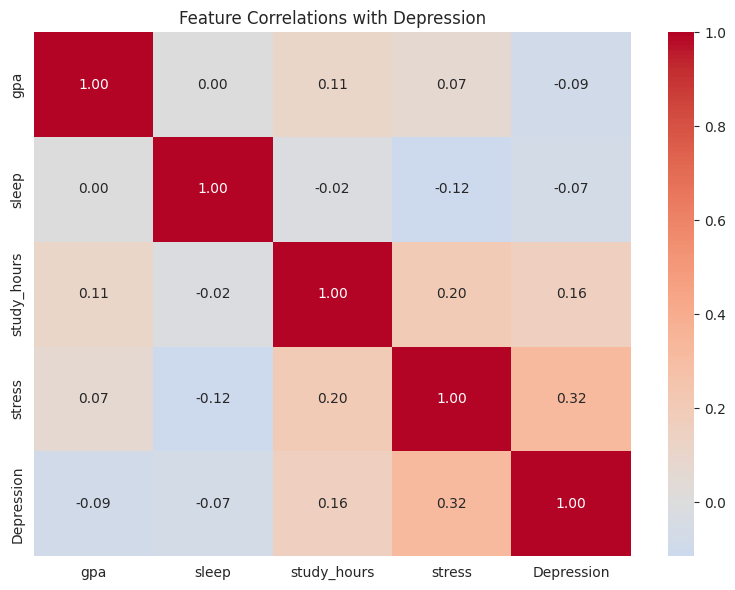

In [35]:
# Feature correlations with target
features = ['gpa', 'sleep', 'study_hours', 'stress']
print("\n" + "="*80)
print("FEATURE-TARGET CORRELATIONS")
print("="*80)
correlations = df_merged[features + ['Depression']].corr()['Depression'].drop('Depression')
print(correlations.sort_values(ascending=False))

# Correlation heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df_merged[features + ['Depression']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlations with Depression')
plt.tight_layout()
plt.show()

# Section 5: Prepare Data for Model Training

### Objective
Split data into training and testing sets. Scale features ONLY for Logistic Regression (not needed for Random Forest).

In [36]:
# Import sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)

# Select features and target
features = ['gpa', 'sleep', 'study_hours', 'stress']
X = df_merged[features]
y = df_merged['Depression']

print("="*80)
print("TRAIN-TEST SPLIT")
print("="*80)
print(f"Total samples: {len(X):,}")
print(f"Feature columns: {features}")

# Stratified train-test split (keep same depression ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")
print(f"\nTraining set depression rate: {(y_train.sum()/len(y_train))*100:.2f}%")
print(f"Test set depression rate: {(y_test.sum()/len(y_test))*100:.2f}%")

TRAIN-TEST SPLIT
Total samples: 52,368
Feature columns: ['gpa', 'sleep', 'study_hours', 'stress']

Training set: 41,894 samples
Test set: 10,474 samples

Training set depression rate: 43.00%
Test set depression rate: 43.00%


In [37]:
# Scale features ONLY for Logistic Regression
# Random Forest doesn't need scaling (tree-based model)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

print("\n" + "="*80)
print("FEATURE SCALING (for Logistic Regression only)")
print("="*80)
print(f"Scaler: StandardScaler")
print(f"\nScaled training data statistics:")
print(X_train_scaled.describe().round(3))
print(f"\nNote: Random Forest will use unscaled features (X_train, X_test)")


FEATURE SCALING (for Logistic Regression only)
Scaler: StandardScaler

Scaled training data statistics:
             gpa      sleep  study_hours     stress
count  41894.000  41894.000    41894.000  41894.000
mean      -0.000      0.000        0.000      0.000
std        1.000      1.000        1.000      1.000
min       -3.436     -1.633       -1.787     -1.650
25%       -0.902     -0.792       -0.752     -0.949
50%       -0.035      0.007       -0.137      0.103
75%        0.860      0.889        0.639      0.687
max        1.872      1.772        2.095      1.856

Note: Random Forest will use unscaled features (X_train, X_test)


# Section 6: Model Training & Evaluation

### Objective
Train Random Forest and Logistic Regression models, then evaluate their performance.

### 6.2 Import ML Libraries

Import all necessary libraries for model training and evaluation

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, auc)
import matplotlib.pyplot as plt

print("="*80)
print("MACHINE LEARNING LIBRARIES IMPORTED")
print("="*80)
print("\n✓ Models: RandomForestClassifier, LogisticRegression")
print("✓ Metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC")
print("✓ Evaluation: Confusion Matrix, Classification Report, ROC Curve")

8.2 MACHINE LEARNING LIBRARIES IMPORTED

✓ Models: RandomForestClassifier, LogisticRegression
✓ Metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC
✓ Evaluation: Confusion Matrix, Classification Report, ROC Curve


### 6.3 Train Random Forest Classifier


In [40]:
from sklearn.model_selection import GridSearchCV

print("\n" + "="*80)
print("HYPERPARAMETER TUNING - RANDOM FOREST")
print("="*80)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=1
)

print("\n[1] Starting Grid Search (this may take a few minutes)...")
grid_search.fit(X_train, y_train)


rf_model = grid_search.best_estimator_

print(f"\n[2] Best Parameters Found:")
print(grid_search.best_params_)


8.4 HYPERPARAMETER TUNING - RANDOM FOREST

[1] Starting Grid Search (this may take a few minutes)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

[2] Best Parameters Found:
{'class_weight': 'balanced', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 200}


In [41]:
# Make predictions
print("\n[3] Making predictions on train and test sets...")
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
rf_train_proba = rf_model.predict_proba(X_train)[:, 1]
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]
print("    ✓ Predictions complete!")

# Calculate metrics
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)
rf_train_auc = roc_auc_score(y_train, rf_train_proba)
rf_test_auc = roc_auc_score(y_test, rf_test_proba)

print("\n[4] Random Forest Performance:")
print(f"    • Training Accuracy:   {rf_train_acc:.4f} ({rf_train_acc*100:.2f}%)")
print(f"    • Test Accuracy:       {rf_test_acc:.4f} ({rf_test_acc*100:.2f}%)")
print(f"    • Training ROC-AUC:    {rf_train_auc:.4f}")
print(f"    • Test ROC-AUC:        {rf_test_auc:.4f}")
print(f"    • The Gap:              {abs(rf_train_auc - rf_test_auc):.4f}")

# Classification report
print("\n[5] Detailed Test Set Report:")
print(classification_report(y_test, rf_test_pred, target_names=['No Depression', 'Depression']))


[3] Making predictions on train and test sets...
    ✓ Predictions complete!

[4] Random Forest Performance:
    • Training Accuracy:   0.7100 (71.00%)
    • Test Accuracy:       0.7048 (70.48%)
    • Training ROC-AUC:    0.7778
    • Test ROC-AUC:        0.7589
    • The Gap:              0.0189

[5] Detailed Test Set Report:
               precision    recall  f1-score   support

No Depression       0.77      0.68      0.72      5970
   Depression       0.63      0.74      0.68      4504

     accuracy                           0.70     10474
    macro avg       0.70      0.71      0.70     10474
 weighted avg       0.71      0.70      0.71     10474



### 6.4 Train Logistic Regression

**Why Logistic Regression?**
- Linear classification model (interpretable)
- Fast training and prediction
- Provides coefficients showing feature impact
- Good baseline for comparison
- Requires feature scaling for optimal performance

**Configuration**:
- `max_iter=1000`: Max iterations for convergence
- `random_state=42`: Reproducibility
- `solver='lbfgs'`: Good for small-medium datasets
- `class_weight='balanced'`: Handle class imbalance
- `C=1.0`: Regularization strength

In [43]:
print("\n" + "="*80)
print("LOGISTIC REGRESSION - TRAINING")
print("="*80)

# Initialize Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    class_weight='balanced',
    C=1.0
)

print("\n[1] Model initialized with parameters:")
print(f"    • solver: lbfgs")
print(f"    • max_iter: 1000")
print(f"    • class_weight: balanced")

# Train on SCALED data (Logistic Regression requires scaling)
print("\n[2] Training on scaled data...")
lr_model.fit(X_train_scaled, y_train)
print("    ✓ Training complete!")

# Make predictions
print("\n[3] Making predictions on train and test sets...")
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)
lr_train_proba = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
print("    ✓ Predictions complete!")

# Calculate metrics
lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_test_acc = accuracy_score(y_test, lr_test_pred)
lr_train_auc = roc_auc_score(y_train, lr_train_proba)
lr_test_auc = roc_auc_score(y_test, lr_test_proba)

print("\n[4] Logistic Regression Performance:")
print(f"    • Training Accuracy:   {lr_train_acc:.4f} ({lr_train_acc*100:.2f}%)")
print(f"    • Test Accuracy:       {lr_test_acc:.4f} ({lr_test_acc*100:.2f}%)")
print(f"    • Training ROC-AUC:    {lr_train_auc:.4f}")
print(f"    • Test ROC-AUC:        {lr_test_auc:.4f}")

# Classification report
print("\n[5] Detailed Test Set Report:")
print(classification_report(y_test, lr_test_pred, target_names=['No Depression', 'Depression']))


LOGISTIC REGRESSION - TRAINING

[1] Model initialized with parameters:
    • solver: lbfgs
    • max_iter: 1000
    • class_weight: balanced

[2] Training on scaled data...
    ✓ Training complete!

[3] Making predictions on train and test sets...
    ✓ Predictions complete!

[4] Logistic Regression Performance:
    • Training Accuracy:   0.6495 (64.95%)
    • Test Accuracy:       0.6526 (65.26%)
    • Training ROC-AUC:    0.7021
    • Test ROC-AUC:        0.7010

[5] Detailed Test Set Report:
               precision    recall  f1-score   support

No Depression       0.71      0.67      0.69      5970
   Depression       0.59      0.63      0.61      4504

     accuracy                           0.65     10474
    macro avg       0.65      0.65      0.65     10474
 weighted avg       0.66      0.65      0.65     10474



# Section 6.1: Model Evaluation

### Metrics Explained
- **Accuracy**: Overall correctness (%)
- **Precision**: Of predicted depressed, how many actually are?
- **Recall**: Of actual depressed, how many were found?
- **F1-Score**: Balance between Precision and Recall
- **ROC-AUC**: Overall model discrimination ability

In [44]:
print("\n" + "="*80)
print("MODEL COMPARISON & EVALUATION")
print("="*80)

# Create comparison dataframe
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Random Forest (Test)': [
        accuracy_score(y_test, rf_test_pred),
        precision_score(y_test, rf_test_pred),
        recall_score(y_test, rf_test_pred),
        f1_score(y_test, rf_test_pred),
        roc_auc_score(y_test, rf_test_proba)
    ],
    'Logistic Regression (Test)': [
        accuracy_score(y_test, lr_test_pred),
        precision_score(y_test, lr_test_pred),
        recall_score(y_test, lr_test_pred),
        f1_score(y_test, lr_test_pred),
        roc_auc_score(y_test, lr_test_proba)
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n MODEL PERFORMANCE COMPARISON:")
print("-"*80)
print(comparison_df.to_string(index=False))

# Determine best model
rf_avg = comparison_df['Random Forest (Test)'].mean()
lr_avg = comparison_df['Logistic Regression (Test)'].mean()
best_model = 'Random Forest' if rf_avg > lr_avg else 'Logistic Regression'

print("\n" + "="*80)
print(f"BEST MODEL: {best_model}")
print("="*80)
print(f"Random Forest Average Score:      {rf_avg:.4f}")
print(f"Logistic Regression Average Score: {lr_avg:.4f}")

# Confusion matrices
print("\n CONFUSION MATRICES:")
print("-"*80)
print("\nRandom Forest:")
rf_cm = confusion_matrix(y_test, rf_test_pred)
print(f"  True Negatives:  {rf_cm[0,0]:<6} | False Positives: {rf_cm[0,1]:<6}")
print(f"  False Negatives: {rf_cm[1,0]:<6} | True Positives:  {rf_cm[1,1]:<6}")

print("\nLogistic Regression:")
lr_cm = confusion_matrix(y_test, lr_test_pred)
print(f"  True Negatives:  {lr_cm[0,0]:<6} | False Positives: {lr_cm[0,1]:<6}")
print(f"  False Negatives: {lr_cm[1,0]:<6} | True Positives:  {lr_cm[1,1]:<6}")



MODEL COMPARISON & EVALUATION

 MODEL PERFORMANCE COMPARISON:
--------------------------------------------------------------------------------
   Metric  Random Forest (Test)  Logistic Regression (Test)
 Accuracy              0.704793                    0.652568
Precision              0.634733                    0.590198
   Recall              0.738455                    0.628330
 F1-Score              0.682677                    0.608668
  ROC-AUC              0.758936                    0.701002

BEST MODEL: Random Forest
Random Forest Average Score:      0.7039
Logistic Regression Average Score: 0.6362

 CONFUSION MATRICES:
--------------------------------------------------------------------------------

Random Forest:
  True Negatives:  4056   | False Positives: 1914  
  False Negatives: 1178   | True Positives:  3326  

Logistic Regression:
  True Negatives:  4005   | False Positives: 1965  
  False Negatives: 1674   | True Positives:  2830  


### 6.6 Feature Importance Analysis

**Random Forest Importance**: Based on how much each feature splits the data (higher = more important)

**Logistic Regression Coefficients**:
- Positive coefficients → increases depression risk
- Negative coefficients → decreases depression risk
- Larger magnitude → stronger effect


FEATURE IMPORTANCE - RANDOM FOREST (TOP 10)


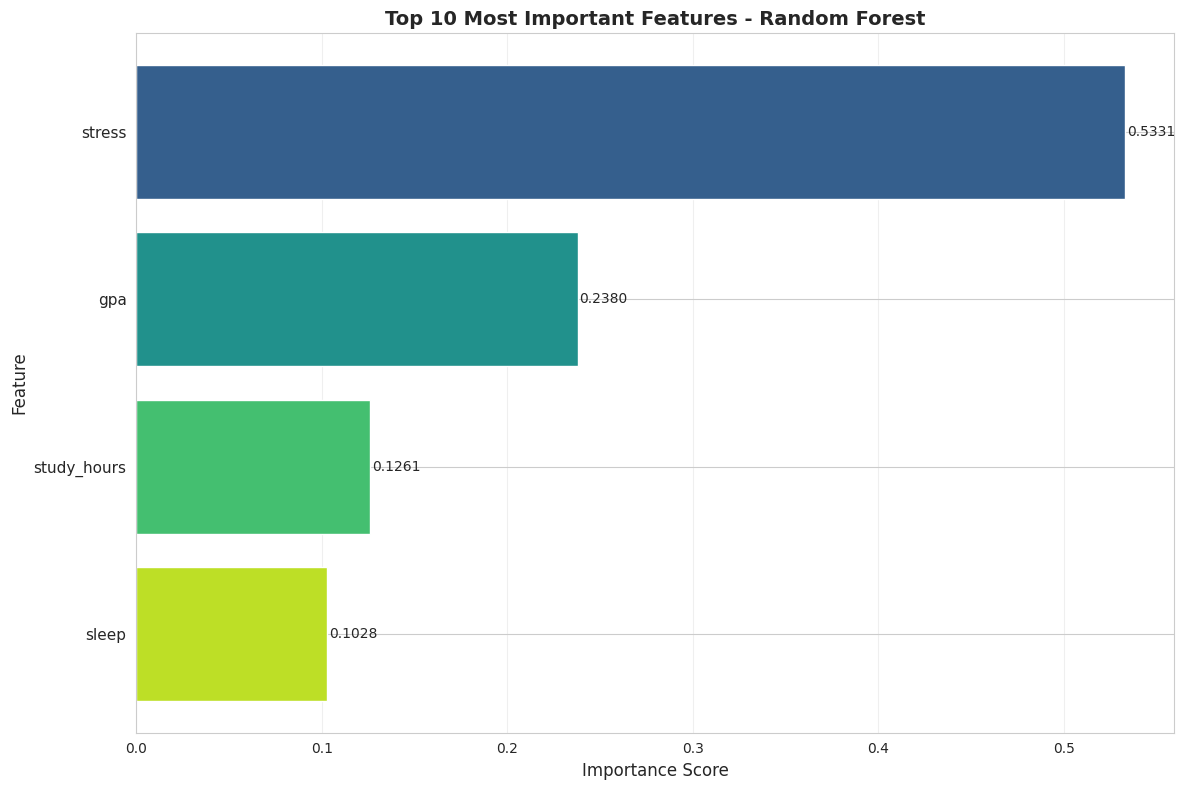

In [51]:
print("\n" + "="*80)
print("FEATURE IMPORTANCE - RANDOM FOREST (TOP 10)")
print("="*80)

plt.figure(figsize=(12, 8))
top_10_features = rf_importance.head(10)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_10_features)))
bars = plt.barh(range(len(top_10_features)), top_10_features['Importance'].values, color=colors)
plt.yticks(range(len(top_10_features)), top_10_features['Feature'].values, fontsize=11)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 10 Most Important Features - Random Forest', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()

# Add value labels on bars
for i, v in enumerate(top_10_features['Importance'].values):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()



CONFUSION MATRIX


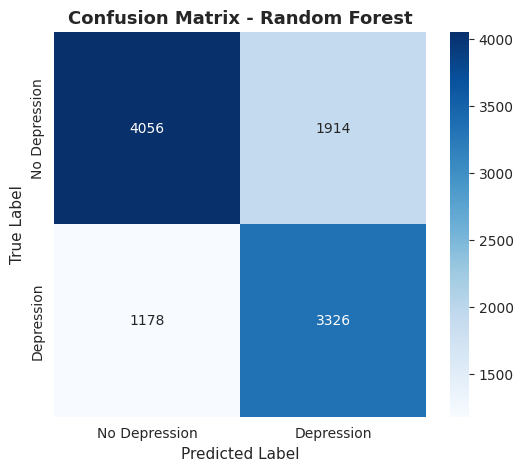

In [60]:
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

plt.figure(figsize=(6, 5))

rf_cm = confusion_matrix(y_test, rf_test_pred)

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])

plt.title('Confusion Matrix - Random Forest', fontweight='bold', fontsize=13)
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)

plt.show()


8.9 ROC CURVES COMPARISON


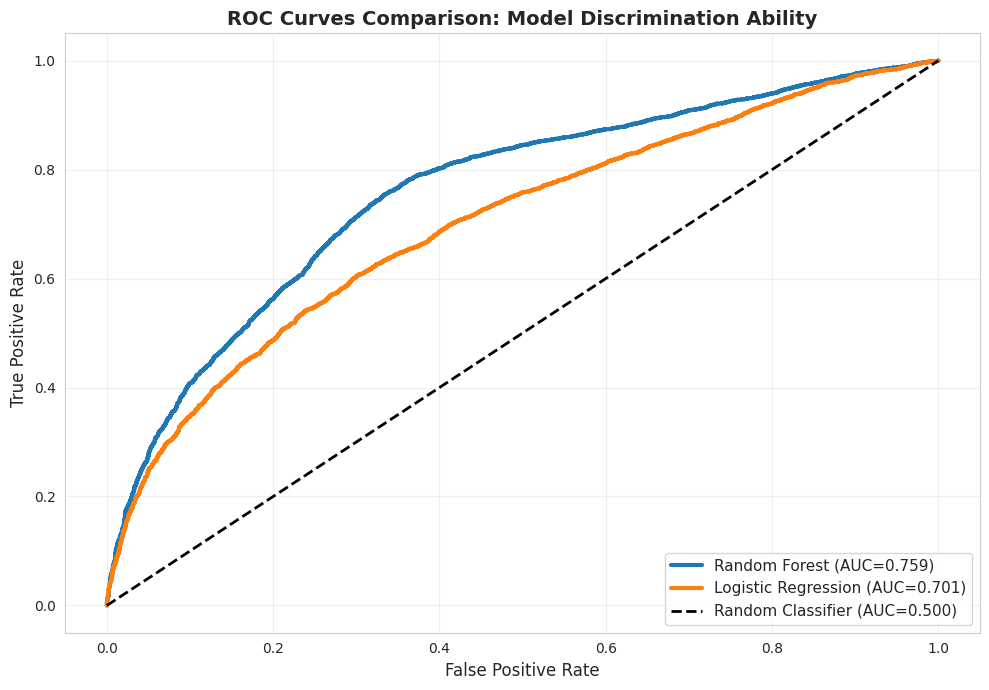

✓ Random Forest AUC:       0.7589
✓ Logistic Regression AUC: 0.7010


In [49]:
print("\n" + "="*80)
print("8.9 ROC CURVES COMPARISON")
print("="*80)

plt.figure(figsize=(10, 7))
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_test_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_test_proba)
rf_auc = auc(fpr_rf, tpr_rf)
lr_auc = auc(fpr_lr, tpr_lr)

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_auc:.3f})', linewidth=3, color='#1f77b4')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_auc:.3f})', linewidth=3, color='#ff7f0e')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC=0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison: Model Discrimination Ability', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✓ Random Forest AUC:       {rf_auc:.4f}")
print(f"✓ Logistic Regression AUC: {lr_auc:.4f}")


PARTIAL DEPENDENCE ANALYSIS
✓ Plotting 4 features


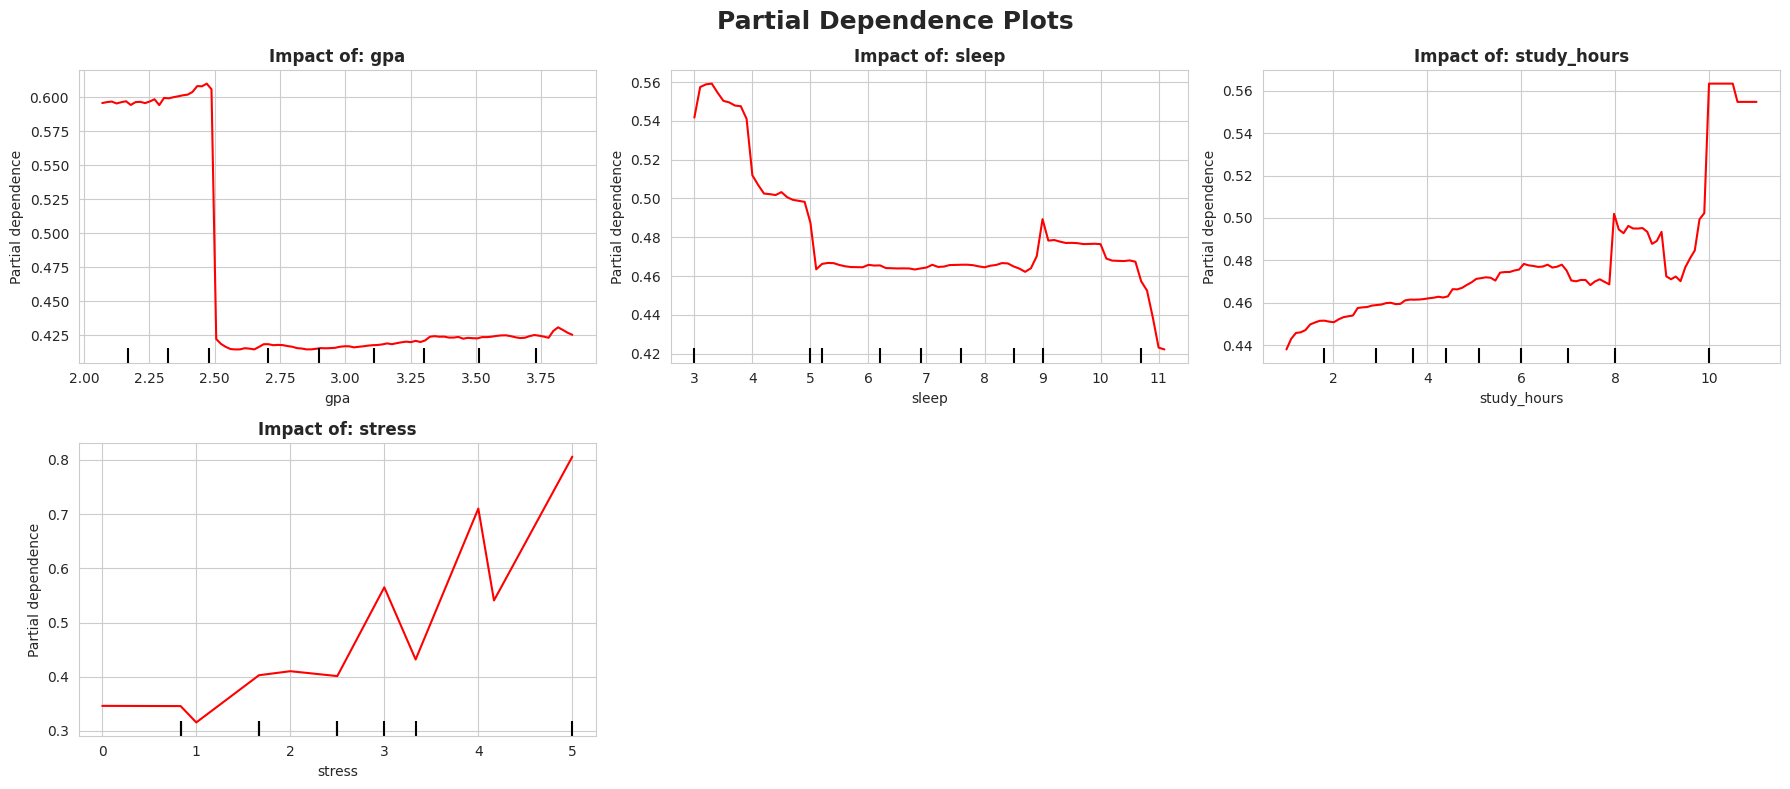

In [50]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

print("\n" + "="*80)
print("PARTIAL DEPENDENCE ANALYSIS")
print("="*80)

X_pdp = X_train.copy()
for col in X_pdp.select_dtypes(include=['bool']).columns:
    X_pdp[col] = X_pdp[col].astype(int)

# Get all features with more than 2 unique values
numerical_only = [feat for feat in X_pdp.columns if X_pdp[feat].nunique() > 2]

print(f"✓ Plotting {len(numerical_only)} features")

n_cols = 3
n_rows = (len(numerical_only) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(numerical_only):
    try:
        PartialDependenceDisplay.from_estimator(
            rf_model,
            X_pdp,
            features=[feature],
            ax=axes[i],
            kind='average',
            line_kw={"color": "red"}
        )
        axes[i].set_title(f"Impact of: {feature}", fontweight='bold')
    except Exception as e:
        axes[i].text(0.5, 0.5, f"Error: {feature}", ha='center', va='center', color='red')

# Hide unused subplots
for j in range(len(numerical_only), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Partial Dependence Plots", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Section 7: Risk Profiling & Student Segmentation

### Objective
Classify students into risk groups based on depression prediction probability.

### Risk Categories
- **HIGH RISK**: Depression probability > 70%
- **MEDIUM RISK**: Depression probability 40-70%
- **LOW RISK**: Depression probability < 40%

In [61]:
# Create risk groups using Random Forest (better performance)
# Use the most important model for risk classification
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

def classify_risk(prob):
    if prob > 0.70:
        return 'HIGH RISK'
    elif prob > 0.40:
        return 'MEDIUM RISK'
    else:
        return 'LOW RISK'

risk_groups = pd.Series(y_pred_proba).apply(classify_risk)

print("="*80)
print("RISK STRATIFICATION RESULTS (Based on Random Forest)")
print("="*80)
print(f"\nRisk Group Distribution:")
print(risk_groups.value_counts())
print(f"\nRisk Group Percentages:")
print(risk_groups.value_counts(normalize=True) * 100)

# Analyze each risk group
print("\n" + "="*80)
print("DEPRESSION RATE BY RISK GROUP")
print("="*80)

risk_df = pd.DataFrame({
    'risk_group': risk_groups,
    'actual_depression': y_test.values,
    'predicted_probability': y_pred_proba
})

for risk in ['HIGH RISK', 'MEDIUM RISK', 'LOW RISK']:
    group = risk_df[risk_df['risk_group'] == risk]
    depression_rate = (group['actual_depression'].sum() / len(group)) * 100
    print(f"\n{risk}:")
    print(f"  Students: {len(group):,}")
    print(f"  Actual depression rate: {depression_rate:.2f}%")
    print(f"  Mean predicted probability: {group['predicted_probability'].mean():.4f}")

RISK STRATIFICATION RESULTS (Based on Random Forest)

Risk Group Distribution:
LOW RISK       4726
MEDIUM RISK    3707
HIGH RISK      2041
Name: count, dtype: int64

Risk Group Percentages:
LOW RISK       45.121253
MEDIUM RISK    35.392400
HIGH RISK      19.486347
Name: proportion, dtype: float64

DEPRESSION RATE BY RISK GROUP

HIGH RISK:
  Students: 2,041
  Actual depression rate: 77.41%
  Mean predicted probability: 0.8128

MEDIUM RISK:
  Students: 3,707
  Actual depression rate: 52.90%
  Mean predicted probability: 0.5798

LOW RISK:
  Students: 4,726
  Actual depression rate: 20.38%
  Mean predicted probability: 0.2607


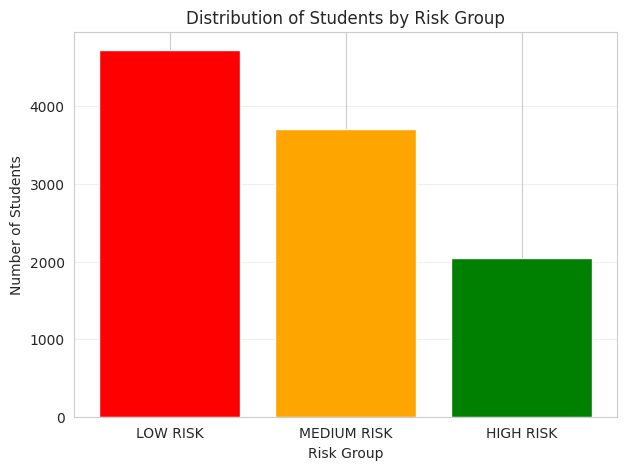

In [67]:
# Visualize risk distribution فقط
plt.figure(figsize=(7, 5))

# Risk group distribution
risk_counts = risk_groups.value_counts()

plt.bar(risk_counts.index, risk_counts.values, color=['red', 'orange', 'green'])
plt.title('Distribution of Students by Risk Group')
plt.ylabel('Number of Students')
plt.xlabel('Risk Group')
plt.grid(axis='y', alpha=0.3)

plt.show()

# Section 8: Summary & Conclusions

In [69]:
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("="*80)
print("FINAL MODEL SUMMARY")
print("="*80)

print(f"\n DATASETS:")
print(f"  • Dataset A: {len(df_a):,} students")
print(f"  • Dataset B: {len(df_b):,} students")
print(f"  • Total: {len(df_merged):,} students")

print(f"\n TARGET VARIABLE:")
print(f"  • Depression Rate: {(df_merged['Depression'].sum() / len(df_merged))*100:.2f}%")
print(f"  • Depressed Students: {df_merged['Depression'].sum():,}")
print(f"  • Non-Depressed Students: {(df_merged['Depression'] == 0).sum():,}")

print(f"\n MODEL PERFORMANCE:")
print(f"  • Best Model: Random Forest")
print(f"  • Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  • Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print(f"  • Test Recall: {recall_score(y_test, y_pred_rf):.4f}")

print(f"\n KEY FEATURES (by importance):")
for idx, row in feature_importance_rf.head(3).iterrows():
    print(f"  • {row['feature']}: {row['importance']:.4f}")

print(f"\n👥 RISK GROUPS:")
for risk in ['HIGH RISK', 'MEDIUM RISK', 'LOW RISK']:
    group = risk_df[risk_df['risk_group'] == risk]
    print(f"  • {risk}: {len(group):,} students ({len(group)/len(risk_df)*100:.1f}%)")

print(f"\n✓ Model training completed successfully!")
print(f"✓ Risk stratification complete!")
print("="*80)

FINAL MODEL SUMMARY

 DATASETS:
  • Dataset A: 22,408 students
  • Dataset B: 29,960 students
  • Total: 52,368 students

 TARGET VARIABLE:
  • Depression Rate: 43.00%
  • Depressed Students: 22,520
  • Non-Depressed Students: 29,848

 MODEL PERFORMANCE:
  • Best Model: Random Forest
  • Test Accuracy: 0.7048
  • Test ROC-AUC: 0.7589
  • Test Recall: 0.7385

 KEY FEATURES (by importance):
  • stress: 0.5331
  • gpa: 0.2380
  • study_hours: 0.1261

👥 RISK GROUPS:
  • HIGH RISK: 2,041 students (19.5%)
  • MEDIUM RISK: 3,707 students (35.4%)
  • LOW RISK: 4,726 students (45.1%)

✓ Model training completed successfully!
✓ Risk stratification complete!
